# TURRET Kalman Filter Analysis Notebook

## Overview

Comprehensive analysis notebook for TURRET captured aircraft tracking and Kalman filter prediction data.

### Sections

1. **Setup and Imports**
2. **Data Loading** - Load captured session data
3. **Data Exploration** - Basic statistics and data quality
4. **Aircraft Tracking Analysis** - Track trajectories and continuity
5. **Kalman Filter Performance** - Covariance, errors, state transitions
6. **Statistical Analysis** - Aircraft counts, rates, stability
7. **Temporal Analysis** - Update intervals, timing, anomalies
8. **Configuration Analysis** - Compare configs and generate recommendations

### Setup

Before running:
- Activate the virtual environment: `source /home/leon/DEV/DOCKER/TURRET/notebooks/venv/bin/activate`
- Ensure capture data exists in the `captures/` directory

In [176]:
# Setup and Imports
import os
import sys
from pathlib import Path
from datetime import datetime

# Add modules to path
module_path = str(Path.cwd() / 'modules')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

# Import analysis modules
from modules.data_loader import DataLoader, create_data_loader
from modules.analysis import KalmanAnalysis, kalman_analysis
from modules.visualization import KalmanVisualizer, kalman_visualizer

# Core data science
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup complete!')
print(f'Module path: {module_path}')
print(f'Current directory: {Path.cwd()}')

Setup complete!
Module path: /home/leon/DEV/DOCKER/TURRET/notebooks/kalman-tuning/modules
Current directory: /home/leon/DEV/DOCKER/TURRET/notebooks/kalman-tuning


In [177]:
# Define captures directory
captures_dir = os.path.abspath(os.path.join('..', '..', 'captures'))

print(f'Captures directory: {captures_dir}')
print(f'Exists: {os.path.exists(captures_dir)}')

# Create data loader
data_loader = create_data_loader(captures_dir)
print('Data loader created!')

Captures directory: /home/leon/DEV/DOCKER/TURRET/captures
Exists: True
Data loader created!


## 1. Data Loading

Load captured data from the TURRET CSV storage backend.

In [178]:
# Find available dates
available_dates = data_loader.find_available_dates()
print('Available dates:')
for date in available_dates:
    print(f'  - {date}')

# Find sessions for latest date
if available_dates:
    latest_date = available_dates[0]
    sessions = data_loader.find_sessions_for_date(latest_date)
    print(f'Sessions for {latest_date}:')
    for session in sessions:
        print(f'  - {os.path.basename(session)}')

Available dates:
  - 2026-08-24
Sessions for 2026-08-24:
  - 2026-08-24_16-18-42_session_0000
  - 2026-08-24_15-18-41_session_0000


In [179]:
# Load all data
print('Loading data...')
predictions, opensky, statistics, metadata_list = data_loader.load_all_data()

print(f'Predictions: {len(predictions)} records')
print(f'OpenSky: {len(opensky)} records')
print(f'Statistics: {len(statistics)} records')
print(f'Sessions: {len(metadata_list)}')

# Show sample data
print('=== Predictions Sample ===')
display(predictions.head(3))

print('=== OpenSky Sample ===')
display(opensky.head(3))

Loading data...
Error loading /home/leon/DEV/DOCKER/TURRET/captures/2026-08-24/2026-08-24_16-18-42_session_0000/statistics.csv: No columns to parse from file
Predictions: 42007 records
OpenSky: 36254 records
Statistics: 1801 records
Sessions: 2
=== Predictions Sample ===


,timestamp,frame_index,session_id,callsign,latitude,longitude,baro_altitude,velocity,true_track,vertical_rate,covariance_lat,covariance_lon,covariance_alt,state,v_north,v_east
0,1.787581e+09,0,624fff22-234f-48b3-a3cf-1b1bf27094c3,AIB04DQ,43.975074,0.810797,3995.234570,202.07,199.17,-30.24,4.727179e-08,9.302302e-08,584.483119,tracking,-190.864902,-66.354156
1,1.787581e+09,0,624fff22-234f-48b3-a3cf-1b1bf27094c3,RYR84XH,43.442061,0.997821,5812.867194,30.87,143.44,0.00,4.723623e-08,9.016776e-08,584.043483,tracking,-24.795819,18.388156
2,1.787581e+09,0,624fff22-234f-48b3-a3cf-1b1bf27094c3,VOE3GE,43.612700,1.536056,10222.351923,242.19,83.78,2.28,4.731507e-08,9.020299e-08,585.018265,tracking,26.240408,240.764277


=== OpenSky Sample ===


,timestamp,frame_index,session_id,callsign,latitude,longitude,baro_altitude,velocity,true_track,vertical_rate,on_ground,v_north,v_east
0,1.787581e+09,0,624fff22-234f-48b3-a3cf-1b1bf27094c3,EJU94VR,43.5854,0.5427,11582.40,242.78,46.97,0.00,False,165.668508,177.471332
1,1.787581e+09,0,624fff22-234f-48b3-a3cf-1b1bf27094c3,WZZ985,43.7818,2.3961,10972.80,209.73,164.05,0.98,False,-201.655787,57.633467
2,1.787581e+09,0,624fff22-234f-48b3-a3cf-1b1bf27094c3,VOE3GE,43.2511,2.4581,10431.78,212.72,169.83,2.93,False,-209.377785,37.559841


In [180]:
# Get combined summary
summary = data_loader.get_combined_summary(predictions, opensky, statistics, metadata_list)

print(f'Sessions: {summary["num_sessions"]}')
print(f'Total predictions: {summary["total_predictions"]}')
print(f'Unique callsigns: {summary["unique_callsigns_predictions"]}')
print(f'States: {summary["state_distribution"]}')

# Kalman configs
for i, config in enumerate(summary['kalman_configs']):
    print(f'Config {i+1}:')
    for k, v in config.items():
        print(f'  {k}: {v}')

Sessions: 2
Total predictions: 42007
Unique callsigns: 116
States: {'tracking': 42007}
Config 1:
  data_update_interval: 10.0
  prediction_interval: 2.0
  max_measurement_age: 60.0
  position_process_noise: 10.0
  velocity_process_noise: 1.0
  position_measurement_noise: 100.0
Config 2:
  data_update_interval: 10.0
  prediction_interval: 2.0
  max_measurement_age: 60.0
  position_process_noise: 10.0
  velocity_process_noise: 1.0
  position_measurement_noise: 100.0


## 2. Data Exploration

Basic statistics and data quality analysis.

In [181]:
# Basic statistics
pred_stats = kalman_analysis.get_basic_statistics(predictions)
os_stats = kalman_analysis.get_basic_statistics(opensky)

print('=== Predictions Statistics ===')
for col, stats in list(pred_stats.items())[:5]:
    print(f'{col}: mean={stats["mean"]:.2f}, std={stats["std"]:.2f}')

print('=== OpenSky Statistics ===')
for col, stats in list(os_stats.items())[:5]:
    print(f'{col}: mean={stats["mean"]:.2f}, std={stats["std"]:.2f}')

=== Predictions Statistics ===
timestamp: mean=1787579434.69, std=1082.29
frame_index: mean=892.72, std=539.79
latitude: mean=43.90, std=0.42
longitude: mean=1.32, std=0.68
baro_altitude: mean=10088.65, std=2513.05
=== OpenSky Statistics ===
timestamp: mean=1787579422.23, std=1097.45
frame_index: mean=909.76, std=549.34
latitude: mean=43.81, std=0.44
longitude: mean=1.25, std=0.72
baro_altitude: mean=10028.49, std=2684.52


In [182]:
# Identify data gaps
pred_gaps = kalman_analysis.identify_data_gaps(predictions)
os_gaps = kalman_analysis.identify_data_gaps(opensky)

print('=== Predictions Gaps ===')
print(f'Total records: {pred_gaps["total_records"]}')
print(f'Missing values: {pred_gaps["total_missing_values"]}')
print(f'Avg time between records: {pred_gaps["avg_time_between_records"]:.4f}s')
print(f'Max gap: {pred_gaps["max_gap"]:.4f}s')
print(f'Gaps > 1s: {pred_gaps["gaps_greater_than_1s"]}')
print(f'Gaps > 5s: {pred_gaps["gaps_greater_than_5s"]}')
print(f'Gaps > 10s: {pred_gaps["gaps_greater_than_10s"]}')

=== Predictions Gaps ===
Total records: 42007
Missing values: 0
Avg time between records: 0.0889s
Max gap: 2.0015s
Gaps > 1s: 1867
Gaps > 5s: 0
Gaps > 10s: 0


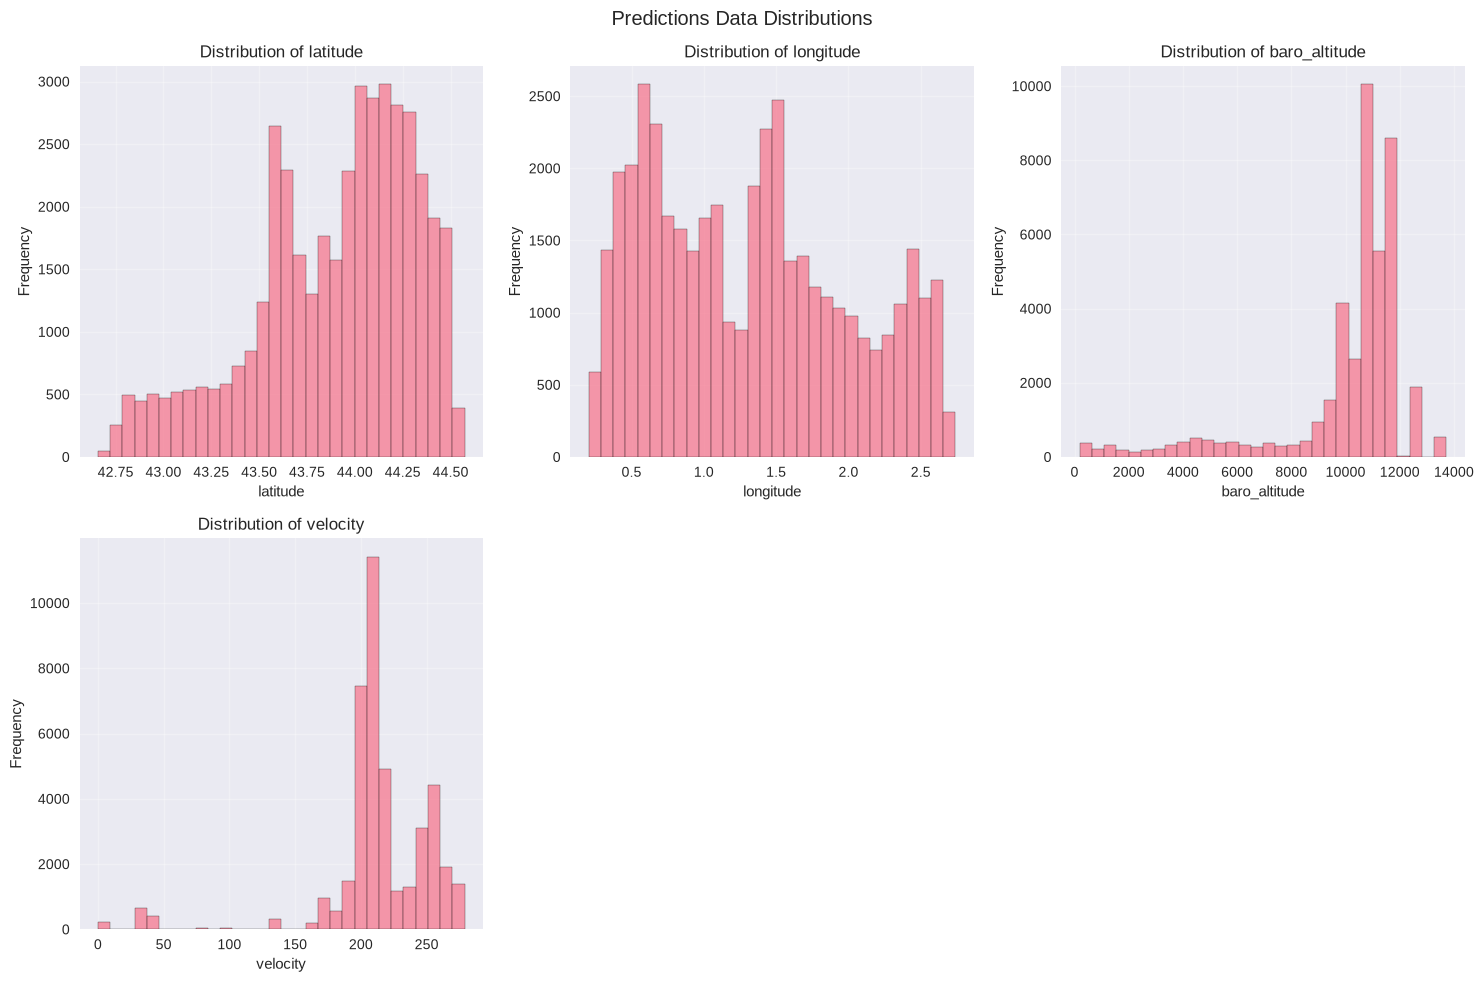

In [183]:
# Plot distributions
key_cols = ['latitude', 'longitude', 'baro_altitude', 'velocity']
plot_cols = [c for c in key_cols if c in predictions.columns]

fig, axes = kalman_visualizer.plot_distribution_histograms(predictions, plot_cols, bins=30)
plt.suptitle('Predictions Data Distributions')
plt.tight_layout()
plt.show()

## 3. Aircraft Tracking Analysis

Track individual aircraft and analyze trajectories.

In [184]:
# Get trajectories
trajectories = kalman_analysis.get_aircraft_trajectories(predictions)
print(f'Found {len(trajectories)} aircraft trajectories')

# Show first few
for callsign in list(trajectories.keys())[:5]:
    print(f'{callsign}: {len(trajectories[callsign])} predictions')

Found 116 aircraft trajectories
AIB04DQ: 1053 predictions
RYR84XH: 661 predictions
VOE3GE: 537 predictions
EZY83FX: 502 predictions
DLH87U: 443 predictions


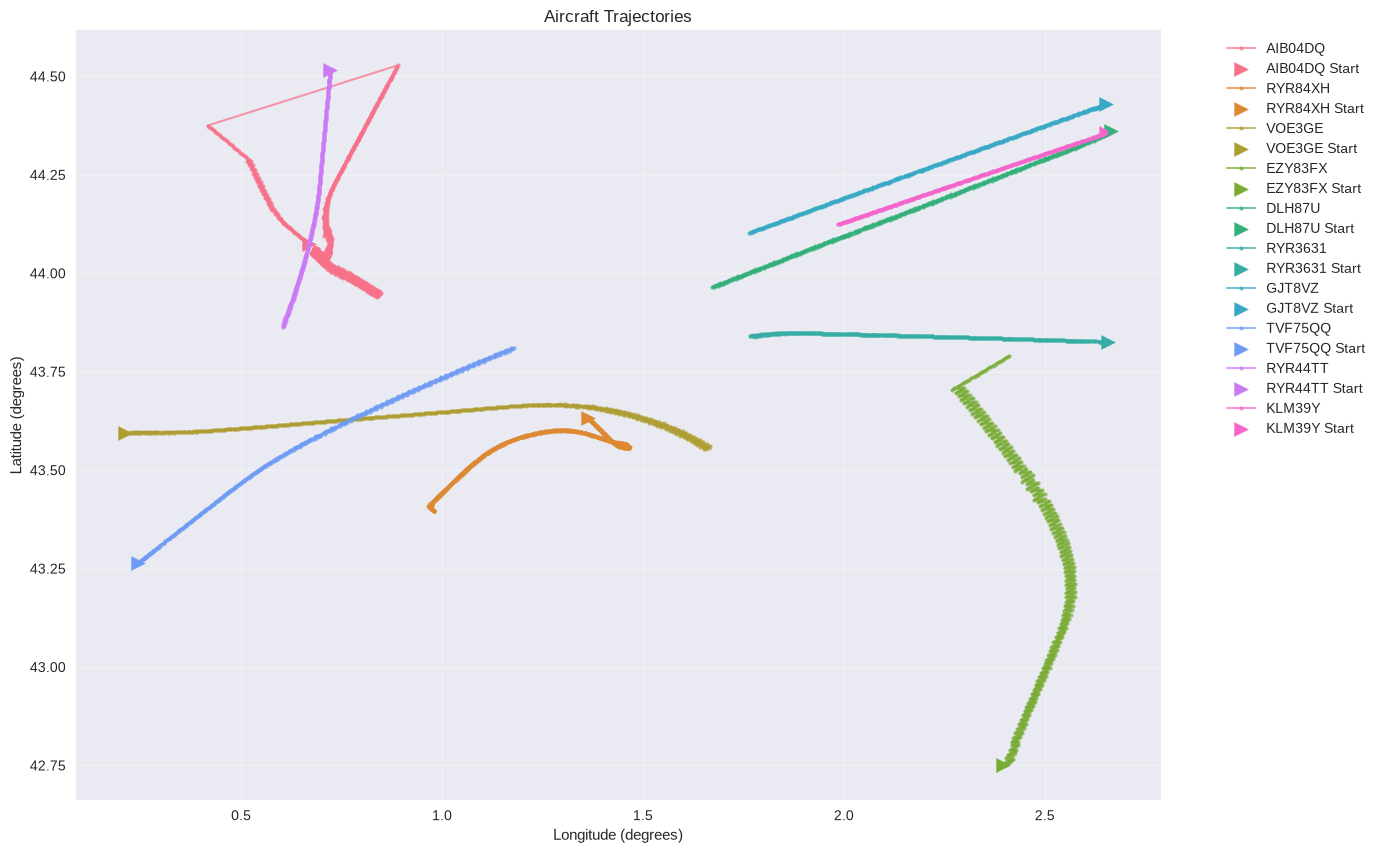

In [185]:
# Plot trajectories
if trajectories:
    sample_callsigns = list(trajectories.keys())[:min(10, len(trajectories))]
    sample_preds = predictions[predictions['callsign'].isin(sample_callsigns)]
    
    fig, ax = kalman_visualizer.plot_aircraft_trajectories(
        sample_preds, callsigns=sample_callsigns, figsize=(14, 10)
    )
    plt.show()

In [186]:
# Track continuity analysis
continuity_results = []
for callsign, trajectory in trajectories.items():
    metrics = kalman_analysis.calculate_track_continuity(trajectory)
    continuity_results.append(metrics)

# Summary
if continuity_results:
    coverages = [m.track_coverage for m in continuity_results]
    print(f'Average track coverage: {np.mean(coverages):.2%}')
    print(f'Median track coverage: {np.median(coverages):.2%}')
    print(f'Average frames per aircraft: {np.mean([m.total_frames for m in continuity_results]):.1f}')

Average track coverage: 84.27%
Median track coverage: 100.00%
Average frames per aircraft: 362.1


In [187]:
# Track accuracy analysis
accuracy_metrics = kalman_analysis.analyze_track_accuracy(predictions, opensky)
print(f'Aircraft with comparison data: {len(accuracy_metrics)}')

# Overall error statistics
error_stats = kalman_analysis.calculate_prediction_error_statistics(predictions, opensky)
if error_stats:
    print(f'\nRMSE Position: {error_stats["rmse_position_m"]:.2f}m')
    print(f'MAE Position: {error_stats["mae_position_m"]:.2f}m')
    print(f'RMSE Altitude: {error_stats["rmse_altitude_m"]:.2f}m')
    print(f'RMSE Velocity: {error_stats["rmse_velocity_knots"]:.2f} knots')

Aircraft with comparison data: 112

RMSE Position: 49986.10m
MAE Position: 40410.15m
RMSE Altitude: 908.17m
RMSE Velocity: 30.68 knots


Plotly not available. Install with: pip install plotly


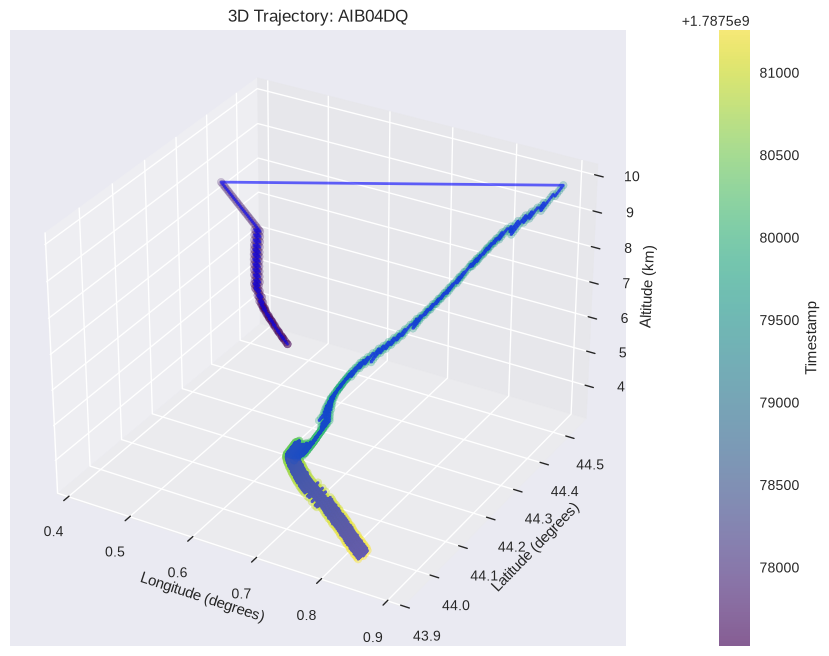

In [188]:
# Interactive 3D trajectory plot
# Try to import plotly for interactive visualization
try:
    import plotly.graph_objects as go
    from modules.visualization import plot_3d_trajectory_interactive
    has_plotly = True
except ImportError:
    has_plotly = False
    print('Plotly not available. Install with: pip install plotly')

if trajectories:
    sample_callsign = list(trajectories.keys())[0]
    # sample_callsign = "JAF6LD"
    trajectory = trajectories[sample_callsign]
    
    if has_plotly:
        # Use interactive 3D plot with Plotly
        fig = plot_3d_trajectory_interactive(trajectory, callsign=sample_callsign)
        if fig:
            fig.show()
    else:
        # Fall back to matplotlib 3D plot
        fig = kalman_visualizer.plot_3d_trajectory(trajectory, callsign=sample_callsign)
        plt.show()

## 4. Kalman Filter Performance

Analyze covariance, prediction errors, and state transitions.

In [172]:
# Covariance convergence analysis
covariance_results = []
for callsign, trajectory in trajectories.items():
    if len(trajectory) >= 5:
        result = kalman_analysis.analyze_covariance_convergence(trajectory)
        covariance_results.append(result)

print(f'Analyzed {len(covariance_results)} aircraft')

# Summary
if covariance_results:
    rates = [r.convergence_rate for r in covariance_results]
    steady = [r.steady_state_reached for r in covariance_results]
    print(f'Avg convergence rate: {np.mean(rates):.2%}')
    print(f'Steady state reached: {sum(steady)}/{len(steady)} ({sum(steady)/len(steady)*100:.1f}%)')

Analyzed 116 aircraft
Avg convergence rate: -36708.25%
Steady state reached: 0/116 (0.0%)


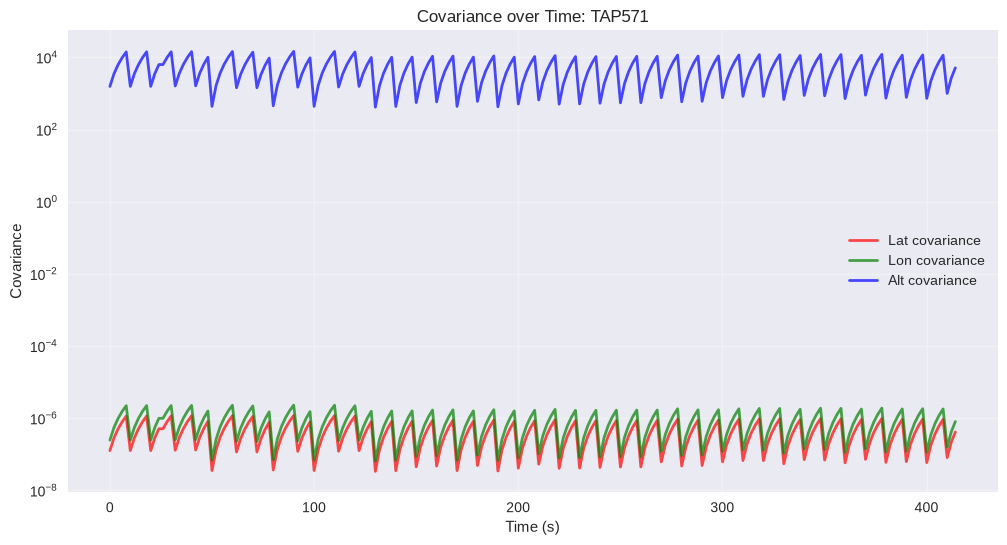

In [173]:
# Plot covariance
if covariance_results:
    best_idx = np.argmax([r.convergence_rate for r in covariance_results])
    best_callsign = covariance_results[best_idx].callsign
    best_traj = trajectories[best_callsign]
    
    fig, ax = kalman_visualizer.plot_covariance_over_time(best_traj, callsign=best_callsign)
    plt.show()

Transition counts:
  tracking->tracking: 41891
State durations (s):
  tracking: 87773.32


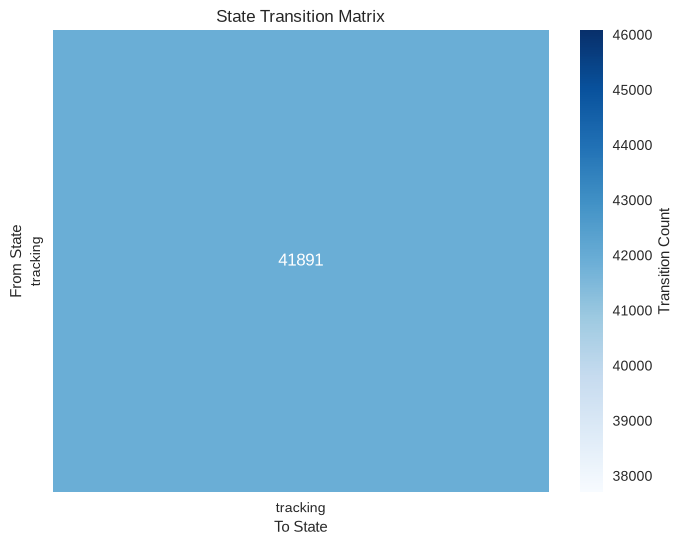

In [174]:
# State transition analysis
state_data = kalman_analysis.analyze_state_transitions(predictions)

print('Transition counts:')
for transition, count in state_data['transition_counts'].items():
    print(f'  {transition}: {count}')

print('State durations (s):')
for state, duration in state_data['state_durations'].items():
    print(f'  {state}: {duration:.2f}')

# Plot transition matrix
if not state_data['state_transition_matrix'].empty:
    fig, ax = kalman_visualizer.plot_state_transition_matrix(state_data['state_transition_matrix'])
    plt.show()

In [175]:
# Velocity vector accuracy
vel_metrics = kalman_analysis.analyze_velocity_vector_accuracy(predictions, opensky)

if vel_metrics:
    print(f'V North RMSE: {vel_metrics["v_north_rmse"]:.4f}')
    print(f'V East RMSE: {vel_metrics["v_east_rmse"]:.4f}')
    print(f'Velocity vector RMSE: {vel_metrics["velocity_vector_rmse"]:.4f}')

V North RMSE: 60.0074
V East RMSE: 72.2406
Velocity vector RMSE: 66.4063


## 5. Statistical Analysis

Aircraft counts, prediction rates, and stability metrics.

In [158]:
# Aircraft count over time
count_data = kalman_analysis.analyze_aircraft_count(statistics)

if len(count_data) > 0:
    fig, ax = kalman_visualizer.plot_aircraft_count(count_data)
    plt.show()
    
    print(f'Max count: {count_data["count"].max():.0f}')
    print(f'Mean count: {count_data["count"].mean():.1f}')
else:
    print('No aircraft count data')

ValueError: Invalid frequency: 1S. Failed to parse with error message: ValueError("Invalid frequency: S. Failed to parse with error message: KeyError('S'). Did you mean s?")

In [ ]:
# Prediction measurement rates
rate_data = kalman_analysis.analyze_prediction_measurement_rates(statistics)

if rate_data:
    print(f'Avg time between frames: {rate_data["avg_time_between_frames"]:.4f}s')
    print(f'Avg predictions per frame: {rate_data["avg_predictions_per_frame"]:.2f}')
    print(f'Total predictions: {rate_data["total_predictions"]}')
    print(f'Total measurements: {rate_data["total_measurements"]}')

In [ ]:
# Track stability metrics
stability = kalman_analysis.calculate_track_stability_metrics(predictions)

if stability:
    print(f'Avg position jump: {stability["avg_position_jump_m"]:.2f}m')
    print(f'Max position jump: {stability["max_position_jump_m"]:.2f}m')
    print(f'Large jumps (>1km): {stability["large_jumps_count"]}')

Avg position jump: 146.29m
Max position jump: 2296.85m
Large jumps (>1km): 66


In [ ]:
# Altitude distribution
alt_data = kalman_analysis.analyze_altitude_distribution(predictions)

if alt_data:
    print(f'Mean altitude: {alt_data["mean_altitude_m"]:.2f}m')
    print(f'Max altitude: {alt_data["max_altitude_m"]:.2f}m')
    print(f'Max climb rate: {alt_data["max_climb_rate_mps"]:.2f}m/s')
    print(f'Max descent rate: {alt_data["max_descent_rate_mps"]:.2f}m/s')

Mean altitude: 9791.76m
Max altitude: 11910.92m
Max climb rate: 77.03m/s
Max descent rate: -42.04m/s


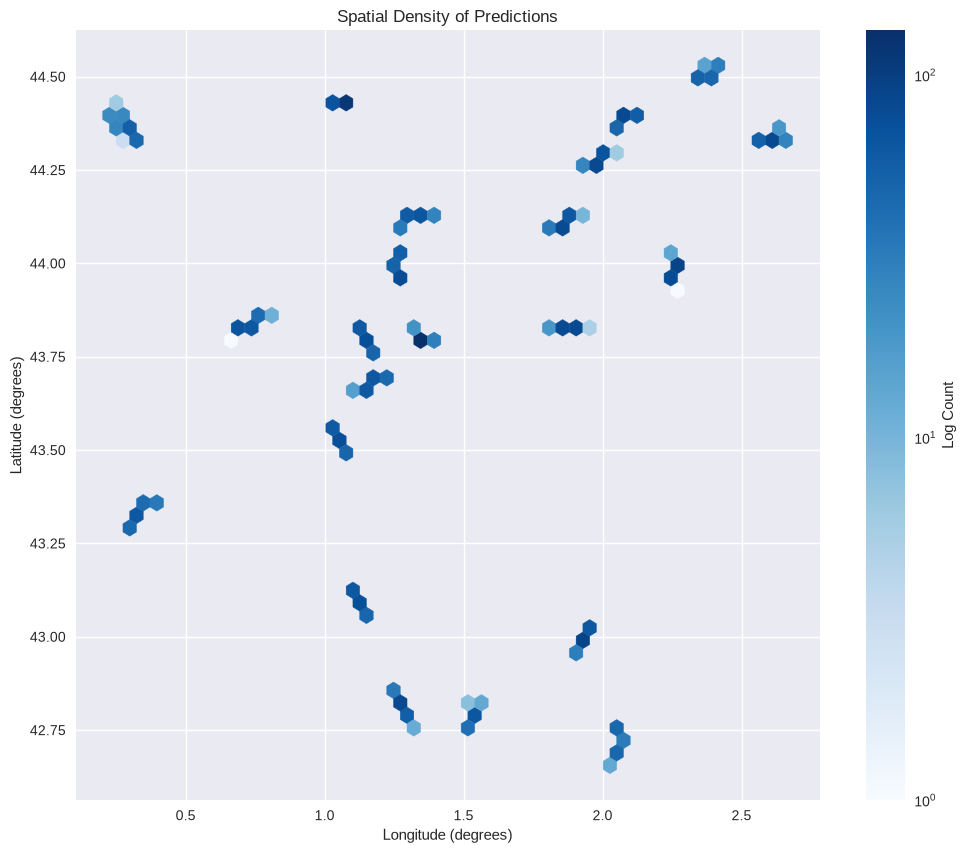

In [ ]:
# Spatial density heatmap
if len(predictions) > 0:
    fig, ax = kalman_visualizer.plot_spatial_density_heatmap(predictions, bins=50)
    plt.show()

## 6. Temporal Analysis

Update intervals, timing consistency, and anomalies.

In [ ]:
# Update interval analysis
if len(statistics) > 0:
    interval_data = kalman_analysis.analyze_update_intervals(statistics)
else:
    mock_stats = predictions.groupby('timestamp').size().reset_index(name='track_count')
    mock_stats['prediction_count'] = mock_stats['track_count']
    mock_stats['total_predictions'] = mock_stats['track_count'].cumsum()
    mock_stats['total_measurements'] = mock_stats['track_count'].cumsum()
    mock_stats['frame_index'] = range(len(mock_stats))
    mock_stats['session_id'] = predictions['session_id'].iloc[0]
    interval_data = kalman_analysis.analyze_update_intervals(mock_stats)

if interval_data:
    print(f'Mean interval: {interval_data["mean_interval_s"]:.4f}s')
    print(f'Std interval: {interval_data["std_interval_s"]:.4f}s')
    print(f'Intervals > 1s: {interval_data["intervals_greater_than_1s"]}')
    print(f'Intervals > 5s: {interval_data["intervals_greater_than_5s"]}')

Mean interval: 0.5006s
Std interval: 0.0003s
Intervals > 1s: 0
Intervals > 5s: 0


In [ ]:
# Timing consistency
if len(statistics) > 0:
    timing = kalman_analysis.analyze_frame_timing_consistency(statistics)
else:
    timing = kalman_analysis.analyze_frame_timing_consistency(mock_stats)

if timing:
    print(f'Expected interval: {timing["expected_interval_s"]:.4f}s')
    print(f'Jitter coefficient: {timing["jitter_coefficient"]:.2%}')

Expected interval: 0.5006s
Jitter coefficient: 0.06%


In [ ]:
# Timing anomalies
if len(statistics) > 0:
    anomalies = kalman_analysis.identify_timing_anomalies(statistics)
else:
    anomalies = kalman_analysis.identify_timing_anomalies(mock_stats)

print(f'Anomalous intervals: {len(anomalies)}')

if len(anomalies) > 0:
    fig, ax = kalman_visualizer.plot_timing_anomalies(anomalies)
    plt.show()

Anomalous intervals: 0


## 7. Configuration Analysis

Compare configurations and generate tuning recommendations.

In [ ]:
# Compare configurations
config_comp = kalman_analysis.compare_configurations(metadata_list)

print(f'Unique configurations: {config_comp["unique_configs"]}')

for i, config in enumerate(config_comp['configurations']):
    print(f'\nConfig {i+1}: {config["session_count"]} sessions')
    print(f'  Process Noise: {config["position_process_noise"]}')
    print(f'  Measurement Noise: {config["position_measurement_noise"]}')

Unique configurations: 1

Config 1: 1 sessions
  Process Noise: 10.0
  Measurement Noise: 100.0


In [ ]:
# Generate recommendations
recommendations = kalman_analysis.generate_configuration_recommendations(
    predictions, opensky, metadata_list
)

print('=== Configuration Recommendations ===')
if recommendations:
    for param, rec in recommendations['recommendations'].items():
        priority = recommendations['priority'].get(param, 'LOW')
        print(f'\n[{priority}] {param}: {rec}')

=== Configuration Recommendations ===

[HIGH] position_process_noise: Increase position process noise to allow for more uncertainty in position changes

[HIGH] altitude_process_noise: Altitude tracking is performing well

[MEDIUM] velocity_process_noise: Velocity tracking is performing well

[HIGH] measurement_noise: Increase measurement noise to account for higher measurement uncertainty


In [ ]:
# Process noise impact
noise_data = kalman_analysis.analyze_process_noise_impact(predictions, metadata_list)

if noise_data:
    print('Process noise levels:', noise_data['noise_levels'])
    for noise, metrics in noise_data['metrics'].items():
        print(f'Noise={noise}: Avg Lat Cov={metrics["avg_covariance_lat"]:.2e}')

Process noise levels: [10.0]
Noise=10.0: Avg Lat Cov=6.28e-07


## 8. Next Steps

### What to do next:

1. Review analysis results and recommendations
2. Tune Kalman filter parameters based on recommendations
3. Run new capture sessions with updated configurations
4. Re-run this notebook to compare performance

### Resources:

- [Kalman Filter Theory](https://en.wikipedia.org/wiki/Kalman_filter)
- TURRET Documentation

---

**Notebook Version**: 1.0.0 | **Last Updated**: 2026-08-24